Klasse mapping:
BlueNoise -> 0
BrownNoise -> 1
Clean -> 2
PinkNoise -> 3
VioletNoise -> 4
WhiteNoise -> 5

Validation Accuracy: 0.9637681159420289

Classification Report (Validation):
              precision    recall  f1-score   support

   BlueNoise       0.94      0.97      0.96        69
  BrownNoise       0.91      0.97      0.94        69
       Clean       0.97      0.91      0.94        69
   PinkNoise       1.00      1.00      1.00        69
 VioletNoise       0.97      0.96      0.96        69
  WhiteNoise       1.00      0.97      0.99        69

    accuracy                           0.96       414
   macro avg       0.96      0.96      0.96       414
weighted avg       0.96      0.96      0.96       414


Confusion Matrix (Validation):
[[67  0  0  0  2  0]
 [ 0 67  2  0  0  0]
 [ 0  6 63  0  0  0]
 [ 0  0  0 69  0  0]
 [ 2  1  0  0 66  0]
 [ 2  0  0  0  0 67]]

Unikke targets i test: [0 1 2 3 4 5]
Antal prøver pr. klasse: [100 100 100 100 100 100]

Test Accuracy: 0.9616666

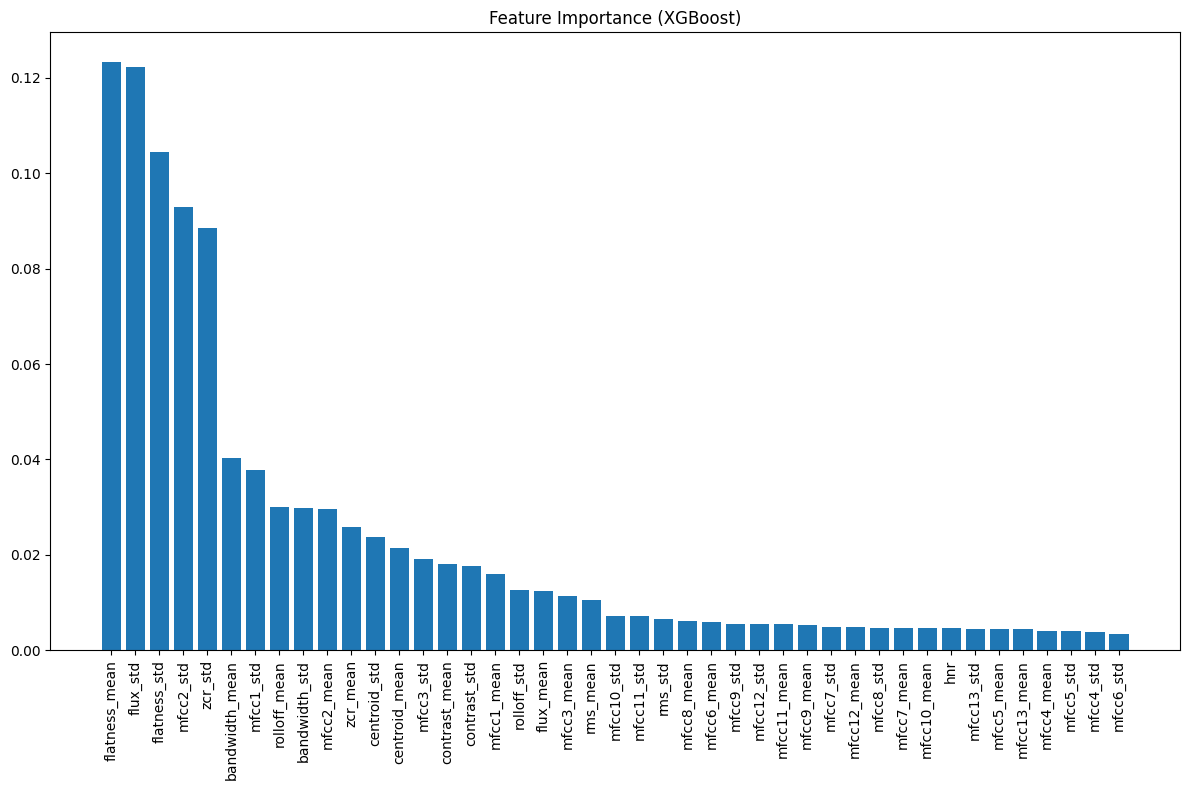


Top 15 vigtigste features:
flatness_mean: 0.1233
flux_std: 0.1223
flatness_std: 0.1043
mfcc2_std: 0.0930
zcr_std: 0.0885
bandwidth_mean: 0.0402
mfcc1_std: 0.0379
rolloff_mean: 0.0299
bandwidth_std: 0.0297
mfcc2_mean: 0.0296
zcr_mean: 0.0258
centroid_std: 0.0237
centroid_mean: 0.0214
mfcc3_std: 0.0191
contrast_mean: 0.0181


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

# ----------------------------
# 1. LOAD TRAINING DATA
# ----------------------------
train_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/TrainingData.csv"
df_train = pd.read_csv(train_path)

# Fjern irrelevant features
irrelevant_cols = ["filnavn", "beta", "snr_db"]  # fjern beta og snr fra features
for col in irrelevant_cols:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])


# ----------------------------
# 2. FEATURES & TARGET
# ----------------------------
X = df_train.drop(columns=["target"])
y = df_train["target"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Klasse mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} -> {i}")

# ----------------------------
# 3. TRAIN / VALIDATION SPLIT
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ----------------------------
# 4. XGBOOST MODEL
# ----------------------------
model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

# ----------------------------
# 5. VALIDATION EVALUATION
# ----------------------------
y_val_pred = model.predict(X_val)

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

# ----------------------------
# 6. TEST ON SEPARATE DATASET
# ----------------------------
test_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/ValidationData.csv"
df_test = pd.read_csv(test_path)


# Fjern irrelevant features
for col in irrelevant_cols:
    if col in df_test.columns:
        df_test = df_test.drop(columns=[col])

# Split features og labels korrekt
X_test = df_test.drop(columns=["target"])
y_test_true = label_encoder.transform(df_test["target"])

# ---- HER PRINTER VI INFO OM TESTDATA ----
print("\nUnikke targets i test:", np.unique(y_test_true))
print("Antal prøver pr. klasse:", np.bincount(y_test_true))

# Lav prediction
y_test_pred = model.predict(X_test)

# Evaluer
print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))

# ----------------------------
# 7. FEATURE IMPORTANCE
# ----------------------------
importances = model.feature_importances_
feature_names = X.columns

# Sorter features efter importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importance (XGBoost)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

# Print top 15 vigtigste features
print("\nTop 15 vigtigste features:")
for i in indices[:15]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")